In [1]:
# make top level dir available
import sys
sys.path.append("../../")

import numpy as np
import functions as myfunc
import meshtools as mt
import matplotlib.pyplot as plt

## Create Custom Mesh

In [2]:
EDGE_LENGTH = 0.01  # custom value
EDGE_OFFSET = 1e-3

RA = 0.3
DD = 0.01
HM = 0.08
BM = 0.08
MA = 0.01
MB = 0.05
RM0 = 0.095
ZM0 = 0.1
LLS = 0.001
SD = 0.005
SH = 0.01

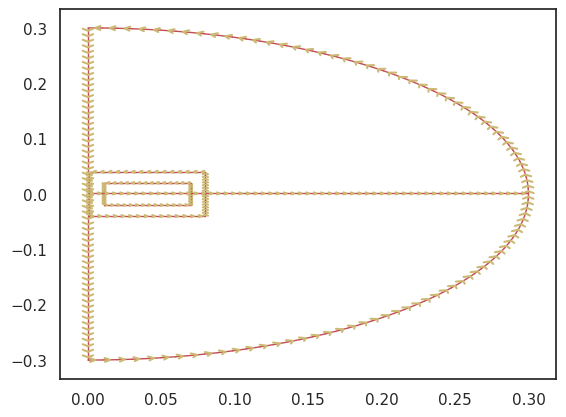

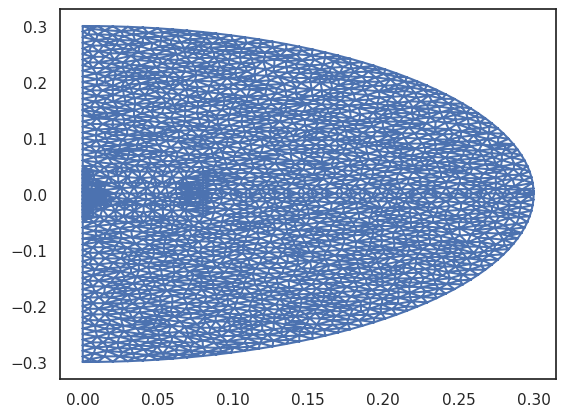

In [3]:
# Randkurve
knots, elements = mt.CircleSegments([0,0], radius=RA, a_min=-np.pi/2, a_max=np.pi/2, edge_length=EDGE_LENGTH)

knots2, elements2 = mt.LineSegments([0, RA], [0, -RA], edge_length=EDGE_LENGTH)
knots, elements = mt.AddSegments(knots, knots2, closed=True)


# Material
knots1, elements1 = mt.RectangleSegments([EDGE_OFFSET, -HM/2], [BM, HM/2], edge_length=EDGE_LENGTH/2)   # outer border
knots, elements = mt.AddCurves(knots, elements, knots1, elements1)

knots5, elements5 = mt.RectangleSegments([EDGE_OFFSET+DD, 2*DD-HM/2], [BM-DD, HM/2-2*DD])  # inner border
knots, elements = mt.AddCurves(knots, elements, knots5, elements5)
 
# # R Achse
knots3, elements3 = mt.LineSegments([EDGE_OFFSET, EDGE_OFFSET], [RA, EDGE_OFFSET], edge_length=EDGE_LENGTH/2)
knots, elements = mt.AddCurves(knots, elements, knots3, elements3)

# def refine_mesh(triangle, area):
def myrefine(tri_points, area):
#   center_tri = np.sum(np.array(tri_points), axis=0)/3.
#   r=center_tri[0]
#   z=center_tri[1]
#   if r<1.05*(RM0+MA/2) and -0.6*HM<z<0.6*HM:
#     max_area=0.033*EDGE_LENGTH**2
#   else: 
#     rho=np.sqrt(r**2+z**2)  
#     max_area=70*EDGE_LENGTH**2*rho
#   return bool(area>max_area)
    pass


    
mt.PlotBoundary(knots, elements, "Segments")
plt.show()
knots,triangles,BouE,li_BE,bou_elem,CuE,li_CE = mt.DoTriMesh(knots, elements, edge_length=EDGE_LENGTH)

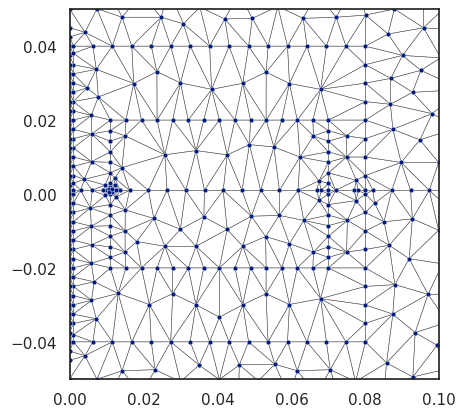

In [4]:
fig, ax = plt.subplots()
ax.set_xlim(0, 0.1)
ax.set_ylim(-0.05, 0.05)
# myfunc.plot_knots_elements(knots, ax=ax)
myfunc.plot_knots_elements(knots, triangles, ax=ax)

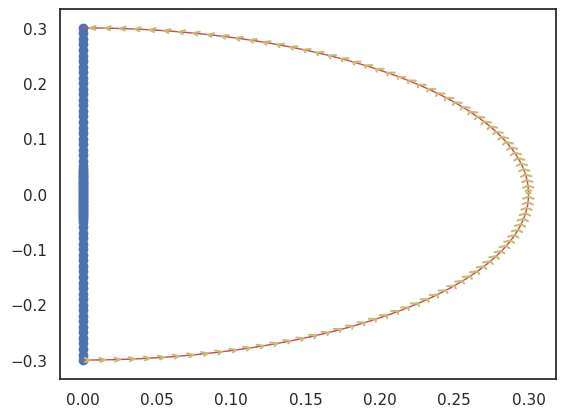

In [5]:
# Randkurven
Ps=[[0,RA],[0,-RA],[0,RA]]
bseg=mt.RetrieveSegments(knots,BouE,li_BE,Ps,['Nodes','Segments'])
mt.PlotBoundary(knots,bseg[0],'Nodes')
mt.PlotBoundary(knots,bseg[1],'Segments')
plt.show()